# Variational Inference

<img src="images/simple_formula.png" width="600"/>

*Simplest formula you will ever encounter in variational inference.*

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

rng = np.random.default_rng(42)

---
## 1. Background: the ELBO

Given observations $x$ and latent variables $z$, we want to compute the posterior $p(z|x)$, which is usually intractable.

Variational Inference introduces a tractable approximation $q(z)$ from a restricted family $Q$, and optimizes it by maximizing the Evidence Lower Bound:

$$\log p(x) = \mathcal{L}(q) + KL[q(z) \| p(z|x)]$$

where

$$\mathcal{L}(q) = \mathbb{E}_q[\log p(x, z) - \log q(z)]$$

$$ KL[q \| p(z|x)] = \mathbb{E}_q[\log q(z) - \log p(z|x)] $$

Since $\log p(x)$ is fixed and $KL \geq 0$, maximizing $\mathcal{L}(q)$ is equivalent to minimizing $KL[q \| p(z|x)]$.


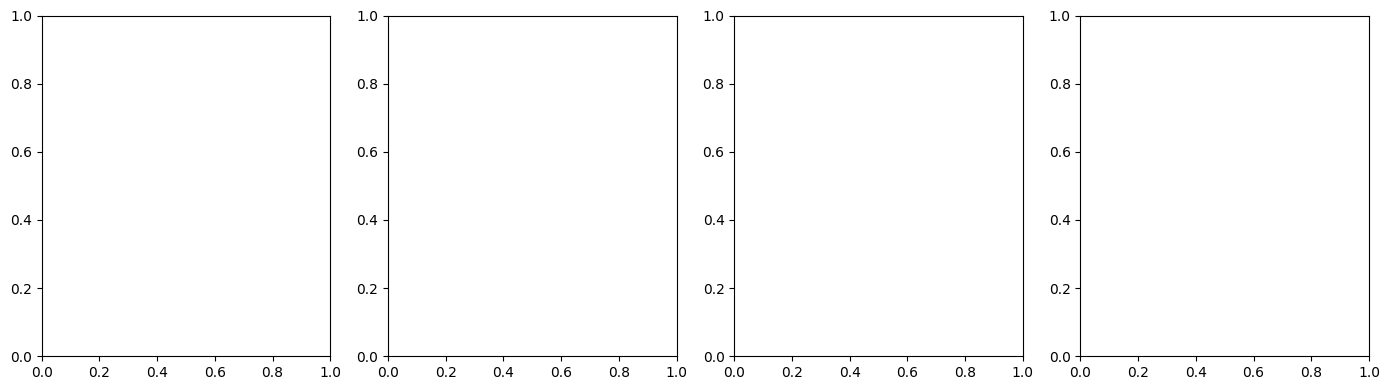

In [ ]:
# Visualize the ELBO decomposition: log p(x) = ELBO + KL
# We use a 1D toy example:
#   p(z|x) = N(2, 1)
#   q(z) = N(mu_q, 1)

z = np.linspace(-2, 6, 500)
true_mu = 2.0
sigma = 1.0

def gaussian_log_pdf(z, mu, sigma):
    return -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((z - mu) / sigma)**2

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
q_means = [0.0, 1.0, 2.0, 3.0]

for ax, mu_q in zip(axes, q_means):
    break

    log_px = 5 # arbitrary normalization value
    
    elbo = log_px - kl

    ax.plot(z, np.exp(log_p), label="p(z|x)", color="steelblue")
    ax.plot(z, q, label=f"q(z), mu={mu_q}", color="tomato", linestyle="--")
    ax.set_title(f"KL={kl:.2f}, ELBO={elbo:.2f}")
    ax.legend(fontsize=8)
    ax.set_xlabel("z")

plt.tight_layout()
plt.show()

---
## Mean Field Variational Inference

The mean field assumption factorizes the variational distribution over $M$ independent blocks:

$$q(z) = \prod_{i=1}^{M} q_i(z_i)$$

The optimal factor for block $j$, keeping all others fixed, is:

$$\log q_j^*(z_j) = \mathbb{E}_{q(z_{-j})}[\log p(x, z_1, ..., z_M)] + \text{const}$$

We cycle through the factors and update each one in turn (coordinate ascent). This is guaranteed to converge since the ELBO is convex in each $q_j$.

### 2D Correlated Gaussian

Consider a 2D Gaussian $p(z) = \mathcal{N}(z | \mu, \Lambda^{-1})$ with a precision matrix $\Lambda$ that has correlated dimensions.

The mean field approximation gives $q(z) = q_1(z_1) q_2(z_2)$, both Gaussian.

The update equations are:
- $q_1^*(z_1) = \mathcal{N}(z_1 | m_1, \Lambda_{11}^{-1}) \quad$ with $\quad m_1 = \mu_1 - \Lambda_{11}^{-1} \Lambda_{12}(\mathbb{E}[z_2] - \mu_2)$
- $q_2^*(z_2) = \mathcal{N}(z_2 | m_2, \Lambda_{22}^{-1}) \quad$ with $\quad m_2 = \mu_2 - \Lambda_{22}^{-1} \Lambda_{21}(\mathbb{E}[z_1] - \mu_1)$

In [3]:
# True distribution: 2D Gaussian with correlated dimensions
mu_true = np.array([0.5, 0.5])

# Precision matrix
Lambda = np.array([[3.0, 2.0],
                   [2.0, 3.0]])

# Covariance matrix (inverse of precision matrix)
Sigma_true = np.linalg.inv(Lambda)

print("True covariance matrix:")
print(Sigma_true)

True covariance matrix:
[[ 0.6 -0.4]
 [-0.4  0.6]]


In [4]:
def mfvi_gaussian_2d(Lambda, mu_true, n_iter=20, m1_init=0.0, m2_init=0.0):
    """
    Coordinate ascent MFVI for a 2D Gaussian.
    Returns the sequence of (m1, m2) variational means and ELBO values.
    """
    pass
    # Initialize L11, mu1, ...


    for _ in range(n_iter):
        # Update q1: m1 depends on E[z2] = m2

        
        # Update q2: m2 depends on E[z1] = m1

        
        # Compute ELBO = -KL[q || p] (up to constant log p(x)
        # For Gaussians: KL[ N(m,S) || N(mu,Sigma)] = 0.5*(tr(Sigma^-1 S) + (m-mu)^T Sigma^-1 (m-mu) - d + log(det(Sigma)/det(S)))


    return history, elbo_history, var1, var2

IndentationError: expected an indented block after 'for' statement on line 10 (1268507242.py, line 21)

In [ ]:
history, elbo_history, var1, var2 = mfvi_gaussian_2d(
    Lambda, mu_true, n_iter=4, m1_init=-1.5, m2_init=3.0
)

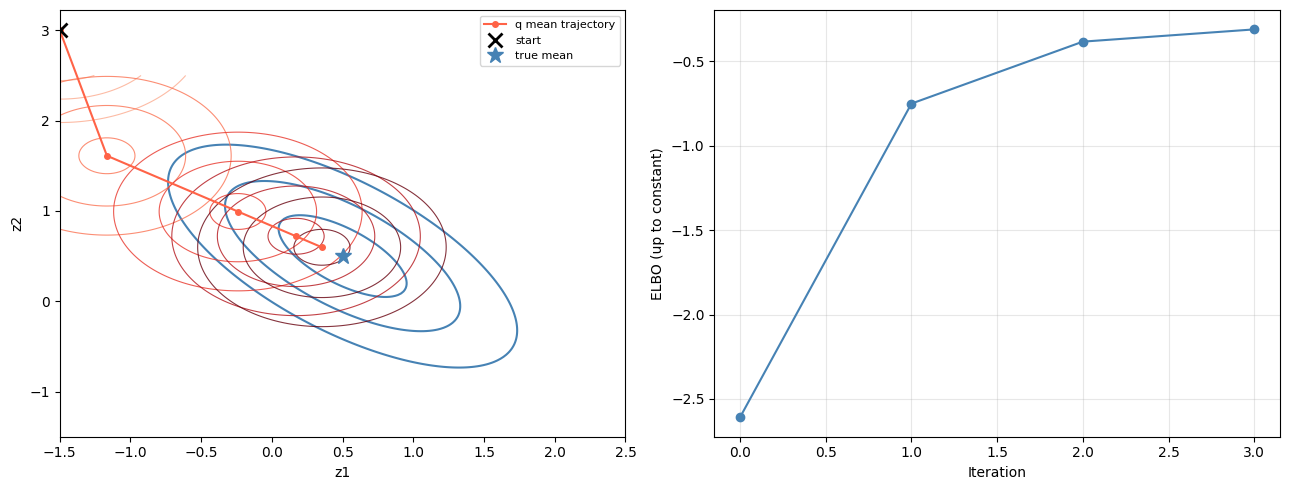

Final variational means: m1=0.3537, m2=0.5975
True means:              mu1=0.5000, mu2=0.5000
Variational variances:   var1=0.3333, var2=0.3333
True marginal variances: 0.6000, 0.6000


In [ ]:
grid_z1 = np.linspace(-1.5, 2.5, 200)
grid_z2 = np.linspace(-1.5, 2.5, 200)
Z1, Z2  = np.meshgrid(grid_z1, grid_z2)
pos = np.stack([Z1, Z2], axis=-1)

true_dist = multivariate_normal(mean=mu_true, cov=np.linalg.inv(Lambda))
P_true = true_dist.pdf(pos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: contour plot of true p and q at each iteration
ax = axes[0]
ax.contour(Z1, Z2, P_true, levels=3, colors="steelblue", linewidths=1.5)

colors = plt.cm.Reds(np.linspace(0.3, 1.0, len(history)))
for i, (m1, m2) in enumerate(history):
    q_cov = np.diag([var1, var2])
    q_dist = multivariate_normal(mean=[m1, m2], cov=q_cov)
    Q = q_dist.pdf(pos)
    ax.contour(Z1, Z2, Q, levels=3, colors=[colors[i]], linewidths=0.8, alpha=0.8)

# Mark starting and ending points
m1_vals = [h[0] for h in history]
m2_vals = [h[1] for h in history]
ax.plot(m1_vals, m2_vals, "o-", color="tomato", markersize=4, label="q mean trajectory")
ax.plot(m1_vals[0], m2_vals[0], "x", color="black", markersize=10, markeredgewidth=2, label="start")
ax.plot(mu_true[0], mu_true[1], "*", color="steelblue", markersize=12, label="true mean")
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.legend(fontsize=8)

# Right: ELBO over iterations
axes[1].plot(elbo_history, "o-", color="steelblue")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("ELBO (up to constant)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final variational means: m1={history[-1][0]:.4f}, m2={history[-1][1]:.4f}")
print(f"True means:              mu1={mu_true[0]:.4f}, mu2={mu_true[1]:.4f}")
print(f"Variational variances:   var1={var1:.4f}, var2={var2:.4f}")
print(f"True marginal variances: {np.linalg.inv(Lambda)[0,0]:.4f}, {np.linalg.inv(Lambda)[1,1]:.4f}")

---
## 3. Direct KL vs Inverse KL

VI as described above minimizes $KL[q \| p]$ (direct). The alternative would be minimizing $KL[p \| q]$ (inverse).

The two have very different behaviors:
- $KL[q \| p]$:  if $p(z) \approx 0$ then $q(z) \approx 0$. The approximation locks onto one mode (zero-forcing).
- $KL[p \| q]$: if $p(z)$ is non-zero then $q(z)$ is non_zero. It tends to cover all modes (zero-avoiding).




In [ ]:
# Target: mixture of two Gaussians (bimodal)
# Approximation family: single Gaussian N(mu_q, sigma_q^2)
# We minimize each KL direction by grid search for clarity

z = np.linspace(-6, 8, 2000)
dz = z[1] - z[0]

# Bimodal target
w1, w2 = 0.5, 0.5
mu1_t, sigma1_t = -1.5, 0.8
mu2_t, sigma2_t = 3.5, 0.8

def gaussian_pdf(z, mu, sigma):
    return np.exp(-0.5 * ((z - mu) / sigma)**2) / (sigma * np.sqrt(2 * np.pi))

p_target = w1 * gaussian_pdf(z, mu1_t, sigma1_t) + w2 * gaussian_pdf(z, mu2_t, sigma2_t)

# Grid search over (mu_q, sigma_q)
mu_grid = np.linspace(-3, 6, 80)
sigma_grid = np.linspace(0.3, 4.0, 80)

best_forward = (np.inf, 0, 1)
best_reverse = (np.inf, 0, 1)

for mu_q in mu_grid:
    for sigma_q in sigma_grid:
        break
        # Compute q

        # Forward KL: KL[q || p]

        # Reverse KL: KL[p || q]


_, mq_fwd, sq_fwd = best_forward
_, mq_rev, sq_rev = best_reverse

print(f"Best forward KL (q||p):  mu={mq_fwd:.2f}, sigma={sq_fwd:.2f}")
print(f"Best reverse KL (p||q):  mu={mq_rev:.2f}, sigma={sq_rev:.2f}")

Best forward KL (q||p):  mu=3.49, sigma=0.82
Best reverse KL (p||q):  mu=0.99, sigma=2.64


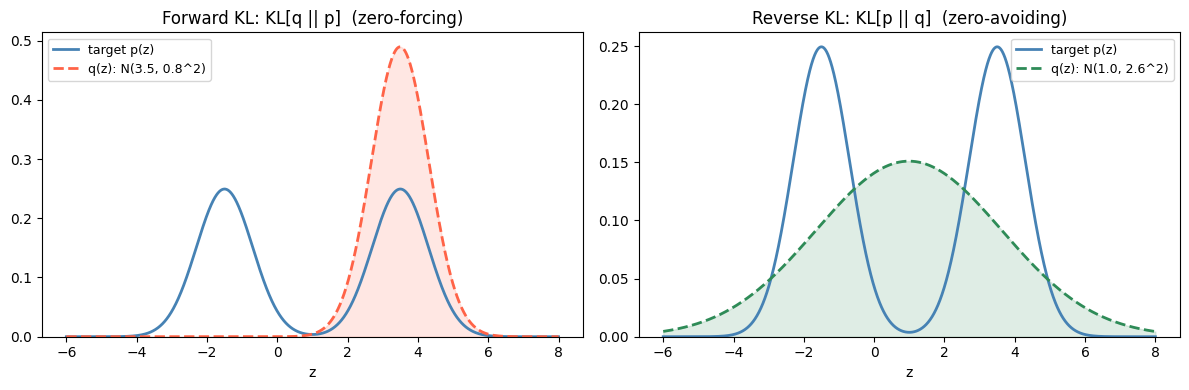

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (mu_q, sigma_q), title, color in zip(
    axes,
    [(mq_fwd, sq_fwd), (mq_rev, sq_rev)],
    ["Forward KL: KL[q || p]  (zero-forcing)", "Reverse KL: KL[p || q]  (zero-avoiding)"],
    ["tomato", "seagreen"]
):
    q_best = gaussian_pdf(z, mu_q, sigma_q)
    ax.plot(z, p_target, color="steelblue", linewidth=2, label="target p(z)")
    ax.plot(z, q_best, color=color, linewidth=2, linestyle="--", label=f"q(z): N({mu_q:.1f}, {sigma_q:.1f}^2)")
    ax.fill_between(z, q_best, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel("z")
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

---
## 4. Reparameterization Trick

In Black Box VI, we want to optimize the ELBO over variational parameters $\lambda$ using gradient ascent:

$$\mathcal{L}(\lambda) = \mathbb{E}_{q(z|\lambda)}[\log p(x, z) - \log q(z|\lambda)]$$

However, the expectation depends on $\lambda$, so we cannot simply swap gradient and expectation to get an unbiased estimate.

The reparameterization trick resolves this. For a Gaussian $q(z|\lambda) = \mathcal{N}(z | \mu, \sigma^2)$, write:

$$z = g(\varepsilon) =\mu + \sigma \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

Now $\varepsilon$ is sampled from a fixed distribution that does not depend on $\lambda = (\mu, \sigma)$, so the gradient can pass through the sampling step.

$$\nabla_{\lambda} \mathcal{L}(\lambda) = \mathbb{E}_{q(\varepsilon)}[\nabla_{\lambda} \log p(x, g(\varepsilon)) - \nabla_{\lambda} \log q(g(\varepsilon)|\lambda)]$$



### ELBO optimization via reparameterization

We now fit a Gaussian variational distribution $q(z) = \mathcal{N}(z | \mu, \sigma^2)$ to a target distribution using gradient ascent on the ELBO, enabled by the reparameterization trick.

The target is a non-symmetric distribution: a mixture of two Gaussians with unequal weights.

In [ ]:
# Target: skewed mixture (heavier on the right mode)
w_target = 0.3
mu1_target, sigma1_target = 0.0, 0.5
mu2_target, sigma2_target = 3.0, 0.7

def log_p_target(z):
    p1 = w_target * gaussian_pdf(z, mu1_target, sigma1_target)
    p2 = (1 - w_target) * gaussian_pdf(z, mu2_target, sigma2_target)
    return np.log(np.clip(p1 + p2, 1e-300, None))

In [ ]:
def elbo_and_grads(mu, log_sigma, n_samples=50):
    sigma = np.exp(log_sigma)
    eps = rng.normal(0, 1, n_samples)
    z = mu + sigma * eps
    
    # 1. Compute ELBO value
    log_pz = log_p_target(z)
    log_qz = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * eps**2
    elbo_val = np.mean(log_pz - log_qz)

    # 2. Numerical gradient of log p(z) w.r.t z
    dz = 1e-5
    grad_p_z = (log_p_target(z + dz) - log_p_target(z - dz)) / (2 * dz)

    # 3. Reparameterization gradients
    # d_ELBO/d_mu = E[ d_logp/dz * dz/dmu ] = E[ d_logp/dz * 1 ]
    grad_mu = np.mean(grad_p_z)
    
    # d_ELBO/d_log_sigma = E[ d_logp/dz * dz/dlog_sigma - d_logq/d_log_sigma ]
    # dz/dlog_sigma = sigma * eps
    # d_logq/dlog_sigma = -1
    grad_log_sigma = np.mean(grad_p_z * (sigma * eps) + 1)

    return elbo_val, grad_mu, grad_log_sigma

In [ ]:
# Gradient ascent
mu = 1.0           # start away from the target
log_sigma = 0.0    # sigma = 1
lr = 0.05
n_iter = 200

elbo_trace = []
mu_trace = []
sigma_trace = []

for i in range(n_iter):
    elbo_val, g_mu, g_ls = elbo_and_grads(mu, log_sigma, n_samples=100)
    mu += lr * g_mu
    log_sigma += lr * g_ls
    elbo_trace.append(elbo_val)
    mu_trace.append(mu)
    sigma_trace.append(np.exp(log_sigma))

print(f"Final mu:    {mu:.3f}")
print(f"Final sigma: {np.exp(log_sigma):.3f}")

Final mu:    2.434
Final sigma: 1.086


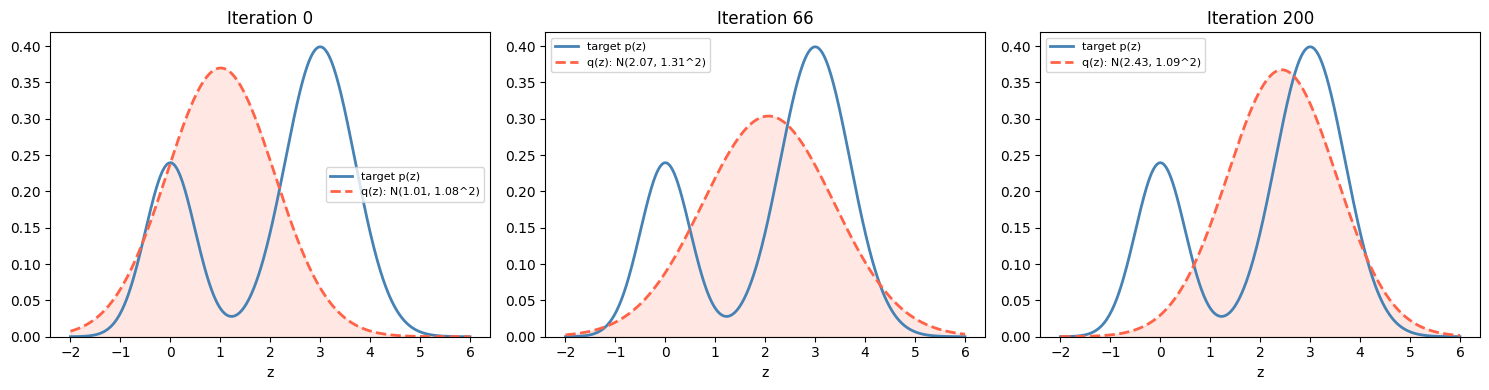

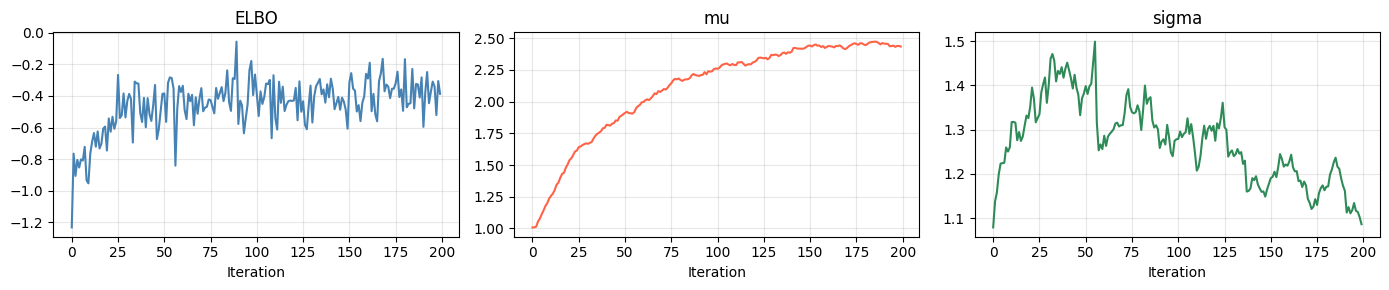

In [ ]:
z_plot = np.linspace(-2, 6, 500)
p_plot = np.exp(log_p_target(z_plot))
p_plot /= np.trapezoid(p_plot, z_plot)   # renormalize for plotting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distributions at three stages
stages = [0, n_iter // 3, n_iter - 1]
stage_labels = ["Iteration 0", f"Iteration {n_iter//3}", f"Iteration {n_iter}"]

for ax, idx, label in zip(axes, stages, stage_labels):
    q_plot = gaussian_pdf(z_plot, mu_trace[idx], sigma_trace[idx])
    ax.plot(z_plot, p_plot, color="steelblue", linewidth=2, label="target p(z)")
    ax.plot(z_plot, q_plot, color="tomato", linewidth=2, linestyle="--",
            label=f"q(z): N({mu_trace[idx]:.2f}, {sigma_trace[idx]:.2f}^2)")
    ax.fill_between(z_plot, q_plot, alpha=0.15, color="tomato")
    ax.set_title(label)
    ax.set_xlabel("z")
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(elbo_trace, color="steelblue")
axes[0].set_title("ELBO")
axes[0].set_xlabel("Iteration")
axes[0].grid(True, alpha=0.3)

axes[1].plot(mu_trace, color="tomato")
axes[1].set_title("mu")
axes[1].set_xlabel("Iteration")
axes[1].grid(True, alpha=0.3)

axes[2].plot(sigma_trace, color="seagreen")
axes[2].set_title("sigma")
axes[2].set_xlabel("Iteration")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Summary

| Method | When to use | Key property |
|---|---|---|
| **Mean Field VI** | When expectations $\mathbb{E}_{i \neq j}[\log p(x,z)]$ are tractable | Coordinate ascent, guaranteed convergence |
| **Reparameterization trick** | When $z = g(\varepsilon; \lambda)$ can be expressed as a deterministic transformation | Low-variance gradient estimates, enables backprop through sampling |
